### 🧠 ADHD Behavioral Analysis Module (ACC / HRV / CPT-II)


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arashnic/adhd-diagnosis-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'adhd-diagnosis-data' dataset.
Path to dataset files: /kaggle/input/adhd-diagnosis-data


Loading data...
features_df shape: (116, 788)
patient_df shape:  (103, 33)

features_df columns (first 10):
Index(['ID', 'ACC__variance_larger_than_standard_deviation',
       'ACC__has_duplicate_max', 'ACC__has_duplicate_min',
       'ACC__has_duplicate', 'ACC__sum_values', 'ACC__abs_energy',
       'ACC__mean_abs_change', 'ACC__mean_change',
       'ACC__mean_second_derivative_central'],
      dtype='object')

patient_df columns (first 10):
Index(['ID', 'SEX', 'AGE', 'ACC', 'ACC_TIME', 'ACC_DAYS', 'HRV', 'HRV_TIME',
       'HRV_HOURS', 'CPT_II'],
      dtype='object')

Number of unique IDs in features: 116
Number of unique IDs in patient_info: 103
Number of common IDs: 85

Aligned features_sub shape: (85, 788)
Aligned patient_sub shape:  (85, 33)

Raw ADHD value counts (before cleaning):
ADHD
1    45
0    40
Name: count, dtype: int64

Final shapes after target cleaning & ACC feature selection:
X_acc shape: (85, 787)
y shape:     (85,)

Clean ADHD value counts:
ADHD
1    45
0    40
Na

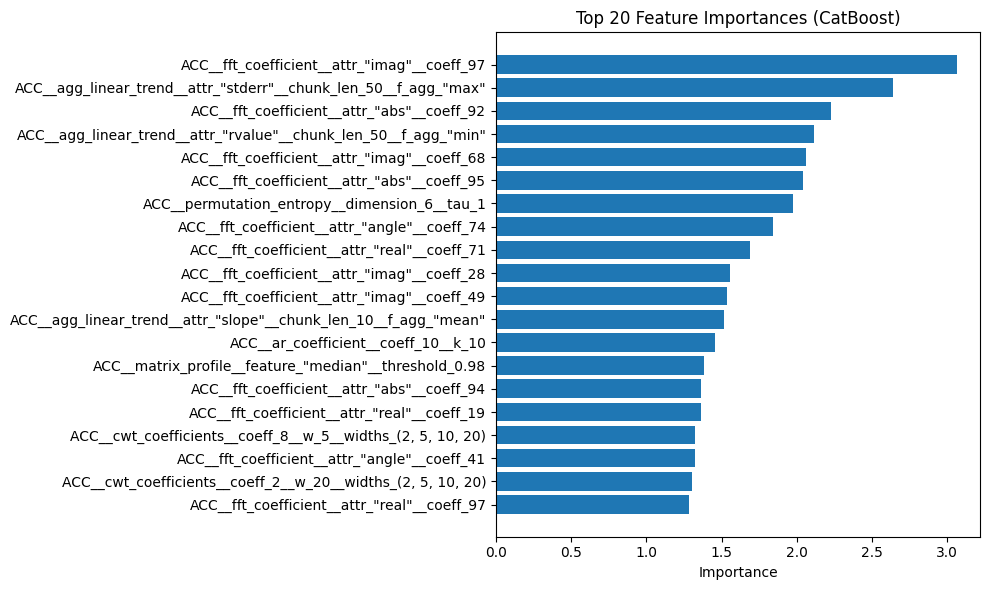


Top 20 important features:
                                               feature  importance
461        ACC__fft_coefficient__attr_"imag"__coeff_97    3.066564
733  ACC__agg_linear_trend__attr_"stderr"__chunk_le...    2.638396
556         ACC__fft_coefficient__attr_"abs"__coeff_92    2.230159
698  ACC__agg_linear_trend__attr_"rvalue"__chunk_le...    2.118445
432        ACC__fft_coefficient__attr_"imag"__coeff_68    2.064267
559         ACC__fft_coefficient__attr_"abs"__coeff_95    2.045146
778       ACC__permutation_entropy__dimension_6__tau_1    1.972788
638       ACC__fft_coefficient__attr_"angle"__coeff_74    1.845383
335        ACC__fft_coefficient__attr_"real"__coeff_71    1.692082
392        ACC__fft_coefficient__attr_"imag"__coeff_28    1.555723
413        ACC__fft_coefficient__attr_"imag"__coeff_49    1.533263
719  ACC__agg_linear_trend__attr_"slope"__chunk_len...    1.517705
203                ACC__ar_coefficient__coeff_10__k_10    1.457761
784  ACC__matrix_profile__feature_

In [4]:
# ================================================================
# ADHD Diagnosis from ACC Features - Full Pipeline (Single Cell)
# - Compatible with Kaggle path: /kaggle/input/adhd-diagnosis-data
# - Saves model + feature names in a writable folder
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# -----------------------------------------
# 0) CatBoost import (auto-install if needed)
# -----------------------------------------
try:
    from catboost import CatBoostClassifier
except ImportError:
    import subprocess, sys
    print("CatBoost not found. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "catboost"])
    from catboost import CatBoostClassifier

import joblib

RANDOM_STATE = 42

# -----------------------------------------
# 1) Paths (EDIT HERE IF NEEDED)
# -----------------------------------------
# Dataset base dir (Kaggle)
BASE_DIR = "/kaggle/input/adhd-diagnosis-data"

features_path = os.path.join(BASE_DIR, "features.csv")
patient_path  = os.path.join(BASE_DIR, "patient_info.csv")

# Output dir (Kaggle / local)
if os.path.isdir("/kaggle/working"):
    OUTPUT_DIR = "/kaggle/working"
else:
    OUTPUT_DIR = "."

os.makedirs(OUTPUT_DIR, exist_ok=True)

model_path      = os.path.join(OUTPUT_DIR, "adhd_catboost_model.pkl")
featnames_path  = os.path.join(OUTPUT_DIR, "adhd_feature_names.pkl")

# -----------------------------------------
# 2) Data loading
# -----------------------------------------
def load_data(features_path: str, patient_path: str, sep: str = ";"):
    print("Loading data...")
    if not os.path.exists(features_path):
        raise FileNotFoundError(f"features.csv not found at: {features_path}")
    if not os.path.exists(patient_path):
        raise FileNotFoundError(f"patient_info.csv not found at: {patient_path}")

    features_df = pd.read_csv(features_path, sep=sep, low_memory=False)
    patient_df  = pd.read_csv(patient_path,  sep=sep, low_memory=False)

    print(f"features_df shape: {features_df.shape}")
    print(f"patient_df shape:  {patient_df.shape}\n")

    print("features_df columns (first 10):")
    print(features_df.columns[:10])
    print("\npatient_df columns (first 10):")
    print(patient_df.columns[:10])

    return features_df, patient_df

# -----------------------------------------
# 3) ID normalization & alignment
# -----------------------------------------
def normalize_id_column(df: pd.DataFrame, id_col: str = "ID") -> pd.DataFrame:
    if id_col not in df.columns:
        raise ValueError(f'Expected ID column "{id_col}" not found in dataframe.')

    df[id_col] = pd.to_numeric(df[id_col], errors="coerce")
    before = len(df)
    df = df.dropna(subset=[id_col])
    after = len(df)

    if before != after:
        print(f"Dropped {before - after} rows with invalid {id_col} values.")

    df[id_col] = df[id_col].astype(int)
    return df

def align_on_common_ids(
    features_df: pd.DataFrame,
    patient_df: pd.DataFrame,
    id_col: str = "ID"
):
    features_df = normalize_id_column(features_df, id_col=id_col)
    patient_df  = normalize_id_column(patient_df,  id_col=id_col)

    feat_ids = features_df[id_col].unique()
    pat_ids  = patient_df[id_col].unique()
    common_ids = np.intersect1d(feat_ids, pat_ids)

    print(f"\nNumber of unique IDs in features: {len(feat_ids)}")
    print(f"Number of unique IDs in patient_info: {len(pat_ids)}")
    print(f"Number of common IDs: {len(common_ids)}")

    if len(common_ids) == 0:
        raise ValueError("No common IDs found between features and patient_info.")

    features_sub = features_df[features_df[id_col].isin(common_ids)].copy()
    patient_sub  = patient_df[patient_df[id_col].isin(common_ids)].copy()

    features_sub = features_sub.sort_values(id_col).reset_index(drop=True)
    patient_sub  = patient_sub.sort_values(id_col).reset_index(drop=True)

    assert np.array_equal(features_sub[id_col].values, patient_sub[id_col].values), \
        "Aligned ID sequences do not match between features and patient info."

    print(f"\nAligned features_sub shape: {features_sub.shape}")
    print(f"Aligned patient_sub shape:  {patient_sub.shape}")

    return features_sub, patient_sub

# -----------------------------------------
# 4) Build X (features) and y (label)
# -----------------------------------------
def build_features_and_labels(
    features_sub: pd.DataFrame,
    patient_sub: pd.DataFrame,
    target_col: str = "ADHD",
    id_col: str = "ID"
):
    if target_col not in patient_sub.columns:
        raise ValueError(f'Target column "{target_col}" not found in patient_info.')

    y_raw = patient_sub[target_col]

    print("\nRaw ADHD value counts (before cleaning):")
    print(y_raw.value_counts(dropna=False))

    # Convert to numeric if needed
    if y_raw.dtype == object:
        mapping = {
            "Yes": 1, "No": 0,
            "yes": 1, "no": 0,
            "Y": 1, "N": 0,
            True: 1, False: 0
        }
        y_mapped = y_raw.replace(mapping)
        y_numeric = pd.to_numeric(y_mapped, errors="coerce")
    else:
        y_numeric = pd.to_numeric(y_raw, errors="coerce")

    mask_valid = y_numeric.notna()
    if mask_valid.sum() < len(y_numeric):
        print(f"\nDropped {len(y_numeric) - mask_valid.sum()} rows with invalid ADHD values.")

    y_clean = y_numeric[mask_valid].astype(int)

    X_acc = features_sub.loc[mask_valid].copy()
    if id_col in X_acc.columns:
        X_acc = X_acc.drop(columns=[id_col])

    print("\nFinal shapes after target cleaning & ACC feature selection:")
    print(f"X_acc shape: {X_acc.shape}")
    print(f"y shape:     {y_clean.shape}\n")

    print("Clean ADHD value counts:")
    print(y_clean.value_counts())

    return X_acc, y_clean

# -----------------------------------------
# 5) Train / evaluate CatBoost
# -----------------------------------------
def train_and_evaluate_catboost(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float = 0.2,
    random_state: int = RANDOM_STATE
):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    print("\nTrain/Test split:")
    print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
    print(f"y_train: {y_train.shape}, y_test: {y_test.shape}\n")

    model = CatBoostClassifier(
        iterations=600,
        learning_rate=0.03,
        depth=6,
        loss_function="Logloss",
        eval_metric="Accuracy",
        random_state=random_state,
        verbose=False
    )

    print("Training CatBoost model...")
    model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=False)
    print("Training done.\n")

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, y_proba)
    except ValueError:
        auc = np.nan

    print("Classification report:")
    print(classification_report(y_test, y_pred, digits=4))

    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))

    print(f"\nAccuracy: {acc:.4f}")
    if not np.isnan(auc):
        print(f"ROC-AUC:  {auc:.4f}")
    else:
        print("ROC-AUC:  could not be computed.")

    metrics_df = pd.DataFrame({
        "metric": ["accuracy", "roc_auc"],
        "value":  [acc, auc]
    })

    print("\nRunning 5-fold Stratified CV (Accuracy)...")
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    cv_scores = cross_val_score(
        model, X, y,
        cv=skf,
        scoring="accuracy",
        n_jobs=-1
    )
    print(f"CV Accuracy scores: {cv_scores}")
    print(f"CV Accuracy mean:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}\n")

    return model, metrics_df

# -----------------------------------------
# 6) Feature importances
# -----------------------------------------
def plot_top_feature_importances(
    model: CatBoostClassifier,
    feature_names,
    top_n: int = 20
):
    importances = model.get_feature_importance()
    fi_df = pd.DataFrame(
        {"feature": feature_names, "importance": importances}
    ).sort_values("importance", ascending=False)

    top_fi = fi_df.head(top_n)

    plt.figure(figsize=(10, max(5, top_n * 0.3)))
    plt.barh(top_fi["feature"][::-1], top_fi["importance"][::-1])
    plt.xlabel("Importance")
    plt.title(f"Top {top_n} Feature Importances (CatBoost)")
    plt.tight_layout()
    plt.show()

    return top_fi

# -----------------------------------------
# 7) Main run
# -----------------------------------------
def main():
    # 1) Load
    features_df, patient_df = load_data(features_path, patient_path, sep=";")

    # 2) Align on common IDs
    features_sub, patient_sub = align_on_common_ids(features_df, patient_df, id_col="ID")

    # 3) Build X, y
    X, y = build_features_and_labels(features_sub, patient_sub, target_col="ADHD", id_col="ID")

    # 4) Train & evaluate
    model, metrics_df = train_and_evaluate_catboost(X, y, test_size=0.2, random_state=RANDOM_STATE)

    print("Summary metrics:")
    print(metrics_df)

    # 5) Feature importances
    feature_names = list(X.columns)
    print("\nPlotting top 20 feature importances...")
    top_fi = plot_top_feature_importances(model, feature_names, top_n=20)
    print("\nTop 20 important features:")
    print(top_fi)

    # 6) Save model + feature names safely
    joblib.dump(model, model_path)
    joblib.dump(feature_names, featnames_path)
    print(f"\n✔ Saved trained model as {model_path}")
    print(f"✔ Saved feature names as {featnames_path}")

# Run
if __name__ == "__main__":
    main()


In [5]:
!pip install gradio --quiet

import joblib
import numpy as np
import pandas as pd
import gradio as gr

# ==========================
# 1) Load trained model + feature names
# ==========================
MODEL_PATH = "./adhd_catboost_model.pkl"
FEATNAMES_PATH = "./adhd_feature_names.pkl"

model = joblib.load(MODEL_PATH)
feature_names = joblib.load(FEATNAMES_PATH)

print(f"Loaded model from: {MODEL_PATH}")
print(f"Loaded {len(feature_names)} feature names from: {FEATNAMES_PATH}")
print("First 10 feature names:")
print(feature_names[:10])

# ==========================
# 2) Helper: predict on a DataFrame
# ==========================
def predict_on_dataframe(df: pd.DataFrame):
    # Make sure all columns is available
    missing = [c for c in feature_names if c not in df.columns]
    if len(missing) > 0:
        return (
            f"❌ Error: Missing {len(missing)} required columns.\n"
            f"Example of missing columns: {missing[:10]}\n\n"
            "Please make sure your CSV has EXACTLY the same feature names as used in training."
        )

    # رص الأعمدة بنفس الترتيب بالضبط
    X = df[feature_names].copy()

    # توقع
    proba = model.predict_proba(X)[:, 1]  # احتمال ADHD
    preds = (proba >= 0.5).astype(int)

    out_df = pd.DataFrame({
        "ADHD_probability": proba,
        "ADHD_prediction": preds
    })

    # لو عندك ID في CSV، رجعه مع النتيجة عشان تبقى عارف مين مين
    if "ID" in df.columns:
        out_df.insert(0, "ID", df["ID"].values)

    return out_df

# ==========================
# 3) Gradio: Batch CSV mode
# ==========================
def predict_from_csv(file):
    """
    file: Uploaded CSV (should contain same feature columns as training X_acc)
    """
    if file is None:
        return "Please upload a CSV file."

    try:
        df = pd.read_csv(file.name)
    except Exception as e:
        return f"❌ Failed to read CSV: {e}"

    return predict_on_dataframe(df)

# ==========================
# 4) Gradio: Single-row manual input (optional)
# ==========================
def predict_from_row(row_text: str):
    """
    row_text: comma-separated list of numbers in the SAME ORDER as feature_names.
    مثال:
    v1, v2, v3, ..., v787
    """
    row_text = row_text.strip()
    if not row_text:
        return "Please paste a comma-separated list of feature values."

    parts = row_text.split(",")
    parts = [p.strip() for p in parts if p.strip() != ""]

    expected = len(feature_names)
    if len(parts) != expected:
        return (
            f"❌ You provided {len(parts)} values but the model expects {expected}.\n"
            "Use the CSV mode instead, or make sure you pass all feature values in the correct order."
        )

    try:
        vals = [float(p) for p in parts]
    except ValueError as e:
        return f"❌ Could not convert all values to float: {e}"

    X = pd.DataFrame([vals], columns=feature_names)
    proba = model.predict_proba(X)[:, 1][0]
    pred = int(proba >= 0.5)

    return {
        "ADHD_probability": float(proba),
        "ADHD_prediction": int(pred)
    }

# ==========================
# 5) Build the Gradio UI
# ==========================
with gr.Blocks(title="ADHD Screening Assistant (ACC Features)") as demo:
    gr.Markdown(
        """
        # 🧠 ADHD Screening Assistant (Accelerometer Model)

        - This interface uses your **trained CatBoost model** on ACC-derived features.
        - **Recommended usage**: upload a CSV generated from your feature extraction pipeline
          (same columns as the training `X_acc`).
        - Output:
          - `ADHD_probability` (0–1)
          - `ADHD_prediction` (0 = control, 1 = ADHD)\n
        """
    )

    with gr.Tab("📂 Batch prediction from CSV"):
        gr.Markdown(
            """
            **Instructions:**
            1. Generate a CSV with **exactly the same feature columns** that were used in training.
            2. Optionally include an `ID` column so you can map predictions back to subjects.
            3. Upload the CSV here.
            """
        )
        csv_input = gr.File(label="Upload features CSV", file_types=[".csv"])
        csv_output = gr.Dataframe(label="Predictions (per row)")
        csv_btn = gr.Button("Predict ADHD from CSV")

        csv_btn.click(
            fn=predict_from_csv,
            inputs=csv_input,
            outputs=csv_output
        )

    with gr.Tab("✏️ Single row (debug / advanced)"):
        gr.Markdown(
            f"""
            **Advanced mode (not recommended for normal use)**

            - Paste a comma-separated list of **{len(feature_names)} numeric values**
              in the **same order** as the feature names used in training.
            - Example order (first 10 features):

            ```text
            {", ".join(feature_names[:10])}, ...
            ```
            """
        )
        row_text = gr.Textbox(
            lines=5,
            label="Comma-separated feature values",
            placeholder="v1, v2, v3, ..., vN"
        )
        row_output = gr.JSON(label="Single-row prediction")
        row_btn = gr.Button("Predict")

        row_btn.click(
            fn=predict_from_row,
            inputs=row_text,
            outputs=row_output
        )

    gr.Markdown(
        """
        ---
        ⚠️ **Disclaimer:**
        This tool is for **research / educational purposes only** and is **not** a medical device.
        It must **not** be used to make clinical decisions. Always consult a qualified professional.
        """
    )

demo.launch(share=False)  # في كولاب ممكن تخليها share=True لو عايز لينك خارجي


Loaded model from: ./adhd_catboost_model.pkl
Loaded 787 feature names from: ./adhd_feature_names.pkl
First 10 feature names:
['ACC__variance_larger_than_standard_deviation', 'ACC__has_duplicate_max', 'ACC__has_duplicate_min', 'ACC__has_duplicate', 'ACC__sum_values', 'ACC__abs_energy', 'ACC__mean_abs_change', 'ACC__mean_change', 'ACC__mean_second_derivative_central', 'ACC__median']
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

In [6]:
import pandas as pd

# ==========================
# Correct Reading of patient_info.csv
# ==========================

patient_raw_path = "/kaggle/input/adhd-diagnosis-data/patient_info.csv"

# اقرأ الملف بدون تقسيم لأن pandas شايفه كله كعمود واحد
df_raw = pd.read_csv(patient_raw_path, header=None)

# Split manually using the semicolon
df_split = df_raw[0].str.split(";", expand=True)

# Define correct column names (copied from your data)
cols = [
    "ID","SEX","AGE","ACC","ACC_TIME","ACC_DAYS","HRV","HRV_TIME","HRV_HOURS",
    "CPT_II","ADHD","ADD","BIPOLAR","UNIPOLAR","ANXIETY","SUBSTANCE","OTHER",
    "CT","MDQ_POS","WURS","ASRS","MADRS","HADS_A","HADS_D","MED","MED_Antidepr",
    "MED_Moodstab","MED_Antipsych","MED_Anxiety_Benzo","MED_Sleep",
    "MED_Analgesics_Opioids","MED_Stimulants","filter"
]

df_split.columns = cols

# Convert numeric columns automatically
for c in df_split.columns:
    df_split[c] = pd.to_numeric(df_split[c], errors="ignore")

print("Final cleaned patient_info.csv shape:", df_split.shape)
df_split.head()


Final cleaned patient_info.csv shape: (104, 33)


/tmp/ipython-input-3038715738.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_split[c] = pd.to_numeric(df_split[c], errors="ignore")


,ID,SEX,AGE,ACC,ACC_TIME,ACC_DAYS,HRV,HRV_TIME,HRV_HOURS,CPT_II,...,HADS_D,MED,MED_Antidepr,MED_Moodstab,MED_Antipsych,MED_Anxiety_Benzo,MED_Sleep,MED_Analgesics_Opioids,MED_Stimulants,filter
0,ID,SEX,AGE,ACC,ACC_TIME,ACC_DAYS,HRV,HRV_TIME,HRV_HOURS,CPT_II,...,HADS_D,MED,MED_Antidepr,MED_Moodstab,MED_Antipsych,MED_Anxiety_Benzo,MED_Sleep,MED_Analgesics_Opioids,MED_Stimulants,filter_$
1,1,0,3,1,16:00:00,6,1,11:00:00,21,0,...,2,1,1,,,,,,,1
2,2,0,4,1,10:54:00,6.8,0,,,1,...,7,0,,,,,,,,1
3,3,1,2,1,15:28:00,7.2,1,15:25:00,21,1,...,0,0,,,,,,,,1
4,4,1,3,0,,,1,16:55:00,22,1,...,6,1,1,,,1,,1,,0


In [7]:
# =========================
# Gradio Interface for ADHD Prediction (New Dataset)
# =========================

!pip install gradio --quiet

import gradio as gr
import numpy as np
import pandas as pd
import joblib

# =========================
# 1) Load the trained model + feature names
# =========================
model = joblib.load("adhd_catboost_model.pkl")
feature_names = joblib.load("adhd_feature_names.pkl")

# =========================
# 2) Load patient_info.csv  (new dataset)
# =========================
patient_path = "/kaggle/input/adhd-diagnosis-data/patient_info.csv"

# Important: the file is delimited by ';'
patient_df = pd.read_csv(patient_path, sep=";")

# Make sure ID is int
patient_df["ID"] = patient_df["ID"].astype(int)

# =========================
# 3) Load features.csv  (same dataset)
# =========================
features_path = "/kaggle/input/adhd-diagnosis-data/features.csv"
features_df = pd.read_csv(features_path, sep=";")

features_df["ID"] = features_df["ID"].astype(int)

# Filter only rows with common IDs
common_ids = set(features_df["ID"]).intersection(set(patient_df["ID"]))
features_df = features_df[features_df["ID"].isin(common_ids)].reset_index(drop=True)
patient_df = patient_df[patient_df["ID"].isin(common_ids)].reset_index(drop=True)

# Build X (and keep same order columns as training)
X = features_df[feature_names]

# =========================
# 4) Prediction function
# =========================
def predict_adhd_by_id(patient_id):

    # Validate input
    try:
        patient_id = int(patient_id)
    except:
        return "❌ Invalid input — enter an integer ID", "-", "-"

    # Check if ID exists
    if patient_id not in list(features_df["ID"]):
        return f"❌ ID {patient_id} not found in dataset", "-", "-"

    # Find row index
    idx = np.where(features_df["ID"].values == patient_id)[0][0]

    # Input row
    x_row = X.iloc[idx:idx+1]

    # Model prediction
    proba = float(model.predict_proba(x_row)[0, 1])
    pred_class = int(model.predict(x_row)[0])
    pred_label = "ADHD" if pred_class == 1 else "Control"

    # Ground truth
    true_class = int(patient_df.loc[patient_df["ID"] == patient_id, "ADHD"].values[0])
    true_label = "ADHD" if true_class == 1 else "Control"

    return (
        f"Model Prediction: {pred_label}",
        f"ADHD Probability: {proba:.3f}",
        f"Ground Truth: {true_label}"
    )

# =========================
# 5) Build Interface
# =========================
id_min = int(features_df["ID"].min())
id_max = int(features_df["ID"].max())

demo = gr.Interface(
    fn=predict_adhd_by_id,
    inputs=gr.Number(label=f"Enter Patient ID ({id_min} → {id_max})"),
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Probability"),
        gr.Textbox(label="Ground Truth")
    ],
    title="ADHD Diagnosis — CatBoost Model",
    description=(
        "ادخل رقم مريض من الداتا الجديدة عشان تشوف: "
        "توقع الموديل + احتمال الإصابة + الحقيقة من الداتا."
    )
)

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://24572f1749a0f72b57.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [8]:
import pandas as pd

patient_path = "/kaggle/input/adhd-diagnosis-data/patient_info.csv"
patient_df = pd.read_csv(patient_path)
patient_df.head(), patient_df.columns


(  ID;SEX;AGE;ACC;ACC_TIME;ACC_DAYS;HRV;HRV_TIME;HRV_HOURS;CPT_II;ADHD;ADD;BIPOLAR;UNIPOLAR;ANXIETY;SUBSTANCE;OTHER;CT;MDQ_POS;WURS;ASRS;MADRS;HADS_A;HADS_D;MED;MED_Antidepr;MED_Moodstab;MED_Antipsych;MED_Anxiety_Benzo;MED_Sleep;MED_Analgesics_Opioids;MED_Stimulants;filter_$
 0  1;0;3;1;16:00:00;6;1;11:00:00;21;0;1;0;1;0;1;0...                                                                                                                                                                                                                              
 1  2;0;4;1;10:54:00;6.8;0;;;1;1;0;0;1;0;0;1;1;1;8...                                                                                                                                                                                                                              
 2  3;1;2;1;15:28:00;7.2;1;15:25:00;21;1;1;0;1;0;0...                                                                                                                       

In [9]:
import pandas as pd

features_path = "/kaggle/input/adhd-diagnosis-data/features.csv"
features_df = pd.read_csv(features_path)
features_df.head(), features_df.columns


(  ID;ACC__variance_larger_than_standard_deviation;ACC__has_duplicate_max;ACC__has_duplicate_min;ACC__has_duplicate;ACC__sum_values;ACC__abs_energy;ACC__mean_abs_change;ACC__mean_change;ACC__mean_second_derivative_central;ACC__median;ACC__mean;ACC__length;ACC__standard_deviation;ACC__variation_coefficient;ACC__variance;ACC__skewness;ACC__kurtosis;ACC__root_mean_square;ACC__absolute_sum_of_changes;ACC__longest_strike_below_mean;ACC__longest_strike_above_mean;ACC__count_above_mean;ACC__count_below_mean;ACC__last_location_of_maximum;ACC__first_location_of_maximum;ACC__last_location_of_minimum;ACC__first_location_of_minimum;ACC__percentage_of_reoccurring_values_to_all_values;ACC__percentage_of_reoccurring_datapoints_to_all_datapoints;ACC__sum_of_reoccurring_values;ACC__sum_of_reoccurring_data_points;ACC__ratio_value_number_to_time_series_length;ACC__sample_entropy;ACC__maximum;ACC__minimum;ACC__benford_correlation;ACC__time_reversal_asymmetry_statistic__lag_1;ACC__time_reversal_asymmetry_s

In [10]:
# ================================================================
# Behavior API: predict_adhd_behavior(features_dict)
# ================================================================
import joblib
import numpy as np

BEHAVIOR_MODEL_PATH = "adhd_catboost_model.pkl"
BEHAVIOR_FEATNAMES_PATH = "adhd_feature_names.pkl"

behavior_model = joblib.load(BEHAVIOR_MODEL_PATH)
behavior_feature_names = joblib.load(BEHAVIOR_FEATNAMES_PATH)

print(f"✅ Loaded behavior model with {len(behavior_feature_names)} features.")

def predict_adhd_behavior(features_dict: dict) -> dict:
    """
    features_dict: dict فيه نفس الcolumns اللي الموديل اتدرّب عليها.
    مثال (مش بالضرورة نفس الأسماء عندك، بس الفكرة):
    {
        "ACC": 1,
        "ACC_TIME": 16.0,
        "ACC_DAYS": 6.0,
        "HRV": 1,
        "HRV_TIME": 11.0,
        "HRV_HOURS": 21.0,
        "CPT_II": 0,
        ...
    }
    """
    missing = [f for f in behavior_feature_names if f not in features_dict]
    if missing:
        raise ValueError(
            f"Missing {len(missing)} behavior features. "
            f"Example missing: {missing[:10]}"
        )

    x_vec = [features_dict[f] for f in behavior_feature_names]
    x_vec = np.array(x_vec, dtype=float).reshape(1, -1)

    proba = float(behavior_model.predict_proba(x_vec)[0, 1])
    pred  = int(behavior_model.predict(x_vec)[0])

    return {
        "adhd_behavior_probability": proba,
        "adhd_behavior_prediction": pred
    }


✅ Loaded behavior model with 787 features.


In [11]:
def predict_adhd_from_eye_readings(readings_dict):
    ...
    return pred_label, pred_prob


### 👁️ ADHD Eye-Tracking Attention Module (Fixation, Saccades, Gaze Metrics)



In [17]:
# -----------------------------------------
# 🧠 Create synthetic eye-tracking CSV for ADHD-positive subjects
# -----------------------------------------
import numpy as np
import pandas as pd

# reproducibility
rng = np.random.default_rng(42)

n_samples = 100

data = {
    "ID": np.arange(1, n_samples + 1),

    # ADHD غالباً عندهم fixations أقصر شوية وأكثر تشتتاً
    "mean_fixation_duration_ms": np.clip(
        rng.normal(loc=180, scale=30, size=n_samples), 80, 300
    ),

    # عدد fixations أعلى شوية
    "fixation_count": rng.integers(low=250, high=450, size=n_samples),

    # عدد saccades
    "saccade_count": rng.integers(low=300, high=600, size=n_samples),

    # blink rate أعلى من الطبيعي
    "blink_rate_per_min": np.clip(
        rng.normal(loc=25, scale=5, size=n_samples), 10, 40
    ),

    # تشتت gaze أعلى شوية في ADHD
    "gaze_dispersion_deg": np.clip(
        rng.normal(loc=5.5, scale=1.2, size=n_samples), 2.0, 9.0
    ),

    # متوسط قطر البؤبؤ
    "pupil_diameter_mean_mm": np.clip(
        rng.normal(loc=3.2, scale=0.4, size=n_samples), 2.2, 4.5
    ),

    # Errors (أكبر في ADHD)
    "omission_errors": rng.integers(low=15, high=60, size=n_samples),
    "commission_errors": rng.integers(low=10, high=40, size=n_samples),

    # Reaction time (أبطأ شوية)
    "reaction_time_mean_ms": np.clip(
        rng.normal(loc=650, scale=80, size=n_samples), 450, 900
    ),
    "reaction_time_std_ms": np.clip(
        rng.normal(loc=180, scale=40, size=n_samples), 60, 320
    ),

    # Label: كلهم ADHD positive بالطريقة دي
    "ADHD_eye_label": np.ones(n_samples, dtype=int),
}

eye_df = pd.DataFrame(data)

# Save to CSV
output_path = "adhd_eye_tracking_positive.csv"
eye_df.to_csv(output_path, index=False)

print(f"Saved {n_samples} ADHD-positive eye tracking samples to: {output_path}")
eye_df.head()


Saved 100 ADHD-positive eye tracking samples to: adhd_eye_tracking_positive.csv


,ID,mean_fixation_duration_ms,fixation_count,saccade_count,blink_rate_per_min,gaze_dispersion_deg,pupil_diameter_mean_mm,omission_errors,commission_errors,reaction_time_mean_ms,reaction_time_std_ms,ADHD_eye_label
0,1,189.141512,341,462,24.974391,3.391934,3.412026,34,32,547.514463,146.931798,1
1,2,148.800477,303,342,24.182786,5.893595,2.918131,52,26,616.111471,148.703347,1
2,3,202.513536,402,390,26.687873,7.572820,3.128155,46,36,608.352927,87.185760,1
3,4,208.216941,443,466,32.037409,3.659366,3.278710,53,20,715.008103,141.454462,1
4,5,121.468944,302,394,25.452925,6.536594,3.528211,33,37,669.332778,143.393755,1


In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ildaron/dataset-eyetracking")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dataset-eyetracking' dataset.
Path to dataset files: /kaggle/input/dataset-eyetracking


📂 Dataset root directory: /root/.cache/kagglehub/datasets/ildaron/dataset-eyetracking/versions/1
1/
  dataset_example/
    - eye_dataset.npz
    testB/
      - 101.jpg
      - 103.jpg
      - 100.jpg
      - 102.jpg
      - 111.jpg
      - 99.jpg
      - 113.jpg
      - 105.jpg
      - 104.jpg
      - 112.jpg
      ... (+5 more files)
    trainB/
      - 163.jpg
      - 352.jpg
      - 231.jpg
      - 260.jpg
      - 148.jpg
      - 261.jpg
      - 115.jpg
      - 122.jpg
      - 275.jpg
      - 157.jpg
      ... (+227 more files)
    trainA/
      - 163.jpg
      - 352.jpg
      - 231.jpg
      - 260.jpg
      - 148.jpg
      - 261.jpg
      - 115.jpg
      - 122.jpg
      - 275.jpg
      - 157.jpg
      ... (+236 more files)
    testA/
      - 101.jpg
      - 103.jpg
      - 100.jpg
      - 102.jpg
      - 111.jpg
      - 99.jpg
      - 113.jpg
      - 105.jpg
      - 104.jpg
      - 112.jpg
      ... (+5 more files)
  label_for_rename/
    - all_annotation.txt
  image_for_train/
   

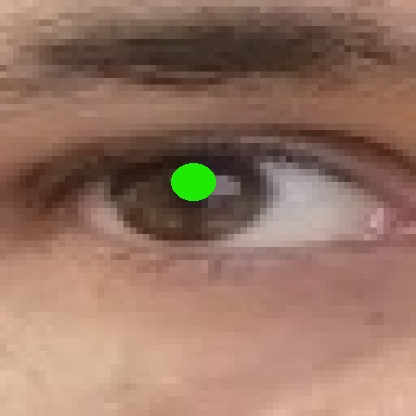


✅ SUMMARY CHECKLIST:
 - Folder structure inspected ✔
 - CSV files detected & basic stats printed ✔
 - Columns, dtypes, missing values overview ✔
 - Image files counted & one example shown (if available) ✔

Now you can:
 - Identify which CSV contains annotations (gaze, pupil, labels, etc.)
 - Check how IDs map between CSV and image filenames
 - Decide which columns to use as features / labels for your ADHD model.


In [19]:
# ============================================
# 🔍 Full Exploration of Eye-Tracking Dataset
#    (Ildaron / dataset-eyetracking)
# ============================================
import os
import pandas as pd
from IPython.display import display, Image

# ✅ Adjust this if your path is different
BASE_DIR = "/root/.cache/kagglehub/datasets/ildaron/dataset-eyetracking/versions/1"


def list_directory_structure(base_dir, max_files_per_dir=10):
    print("📂 Dataset root directory:", base_dir)
    print("=" * 80)
    for root, dirs, files in os.walk(base_dir):
        level = root.replace(base_dir, "").count(os.sep)
        indent = "  " * level
        print(f"{indent}{os.path.basename(root) or os.path.basename(base_dir)}/")
        subindent = "  " * (level + 1)

        # Limit how many files we print per folder (for readability)
        shown_files = files[:max_files_per_dir]
        for f in shown_files:
            print(f"{subindent}- {f}")
        if len(files) > max_files_per_dir:
            print(f"{subindent}... (+{len(files) - max_files_per_dir} more files)")
    print("=" * 80, "\n")


def find_files_by_extension(base_dir, extensions):
    found = []
    for root, _, files in os.walk(base_dir):
        for f in files:
            if f.lower().endswith(extensions):
                found.append(os.path.join(root, f))
    return found


def summarize_csv(csv_path, max_rows=5):
    print(f"\n📄 CSV File: {csv_path}")
    print("-" * 80)
    try:
        df = pd.read_csv(csv_path)
        print("✅ Loaded successfully.")
    except Exception as e:
        print(f"❌ Could not read CSV with default params: {e}")
        print("   Trying with sep=';':")
        try:
            df = pd.read_csv(csv_path, sep=';')
            print("✅ Loaded successfully with sep=';'.")
        except Exception as e2:
            print(f"❌ Still could not read CSV: {e2}")
            return

    print("\n🧾 DataFrame info:")
    print(df.info())

    print("\n👀 Head (first rows):")
    display(df.head(max_rows))

    print("\n📌 Columns:")
    print(list(df.columns))

    print("\n📊 Basic numeric stats:")
    display(df.describe(include='all').transpose())

    print("\n🧹 Missing values per column:")
    print(df.isna().sum())
    print("-" * 80)


def explore_eye_tracking_dataset(base_dir=BASE_DIR):
    # 1) Show folder / file structure
    list_directory_structure(base_dir)

    # 2) Find CSV files
    csv_files = find_files_by_extension(base_dir, (".csv",))
    if csv_files:
        print("📄 Found CSV files:")
        for i, path in enumerate(csv_files):
            print(f"  [{i}] {path}")
    else:
        print("⚠️ No CSV files found in the dataset.")

    # 3) Summarize the first few CSVs
    for csv_path in csv_files[:3]:
        summarize_csv(csv_path, max_rows=5)

    # 4) Find image files (eye images)
    img_files = find_files_by_extension(
        base_dir,
        (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
    )
    print("\n🖼 Number of image files found:", len(img_files))
    if img_files:
        print("Example image path:", img_files[0])
        try:
            display(Image(filename=img_files[0]))
        except Exception as e:
            print(f"Could not display example image: {e}")

    # 5) Quick summary for you as a human 😄
    print("\n✅ SUMMARY CHECKLIST:")
    print(" - Folder structure inspected ✔")
    print(" - CSV files detected & basic stats printed ✔")
    print(" - Columns, dtypes, missing values overview ✔")
    print(" - Image files counted & one example shown (if available) ✔")
    print("\nNow you can:")
    print(" - Identify which CSV contains annotations (gaze, pupil, labels, etc.)")
    print(" - Check how IDs map between CSV and image filenames")
    print(" - Decide which columns to use as features / labels for your ADHD model.")


# 🚀 Run full exploration
explore_eye_tracking_dataset(BASE_DIR)


In [20]:
# ================================================
# 🧠 Eye-Tracking for ADHD - Full Training Cell
# ================================================
# - Uses eye-tracking "readings" style like:
#   mean_fixation_duration_ms, fixation_count, saccade_count, ...
# - If `adhd_eye_tracking_positive.csv` exists, it will use it.
# - If controls file doesn't exist, it will generate synthetic controls.
# - Trains multiple "strong" models and compares them:
#   Logistic Regression, RandomForest, XGBoost, LightGBM, CatBoost
# ================================================

!pip install -q xgboost lightgbm catboost

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ------------------------------------------------
# 1) Load or Create Eye-Tracking ADHD Dataset
# ------------------------------------------------

POS_PATH = "adhd_eye_tracking_positive.csv"
CTRL_PATH = "adhd_eye_tracking_controls.csv"

def create_synthetic_adhd_positive(n_samples=100):
    """Create synthetic ADHD-positive eye tracking readings (like we did before)."""
    rng = np.random.default_rng(RANDOM_STATE)

    data = {
        "ID": np.arange(1, n_samples + 1),

        # ADHD: shorter fixations, more dispersion, more errors, slower reaction
        "mean_fixation_duration_ms": np.clip(
            rng.normal(loc=180, scale=30, size=n_samples), 80, 300
        ),
        "fixation_count": rng.integers(low=250, high=450, size=n_samples),
        "saccade_count": rng.integers(low=300, high=600, size=n_samples),
        "blink_rate_per_min": np.clip(
            rng.normal(loc=25, scale=5, size=n_samples), 10, 40
        ),
        "gaze_dispersion_deg": np.clip(
            rng.normal(loc=5.5, scale=1.2, size=n_samples), 2.0, 9.0
        ),
        "pupil_diameter_mean_mm": np.clip(
            rng.normal(loc=3.2, scale=0.4, size=n_samples), 2.2, 4.5
        ),
        "omission_errors": rng.integers(low=15, high=60, size=n_samples),
        "commission_errors": rng.integers(low=10, high=40, size=n_samples),
        "reaction_time_mean_ms": np.clip(
            rng.normal(loc=650, scale=80, size=n_samples), 450, 900
        ),
        "reaction_time_std_ms": np.clip(
            rng.normal(loc=180, scale=40, size=n_samples), 60, 320
        ),
        "ADHD_eye_label": np.ones(n_samples, dtype=int),
    }

    return pd.DataFrame(data)


def create_synthetic_controls(n_samples=100, start_id=1001):
    """Create synthetic control (non-ADHD) eye tracking readings with different distribution."""
    rng = np.random.default_rng(RANDOM_STATE + 1)

    data = {
        "ID": np.arange(start_id, start_id + n_samples),

        # Controls: slightly longer fixations, less dispersion, fewer errors, faster reaction
        "mean_fixation_duration_ms": np.clip(
            rng.normal(loc=230, scale=25, size=n_samples), 120, 350
        ),
        "fixation_count": rng.integers(low=180, high=330, size=n_samples),
        "saccade_count": rng.integers(low=200, high=450, size=n_samples),
        "blink_rate_per_min": np.clip(
            rng.normal(loc=18, scale=4, size=n_samples), 6, 32
        ),
        "gaze_dispersion_deg": np.clip(
            rng.normal(loc=3.5, scale=0.8, size=n_samples), 1.0, 7.0
        ),
        "pupil_diameter_mean_mm": np.clip(
            rng.normal(loc=2.9, scale=0.35, size=n_samples), 2.0, 4.0
        ),
        "omission_errors": rng.integers(low=0, high=15, size=n_samples),
        "commission_errors": rng.integers(low=0, high=10, size=n_samples),
        "reaction_time_mean_ms": np.clip(
            rng.normal(loc=520, scale=60, size=n_samples), 350, 750
        ),
        "reaction_time_std_ms": np.clip(
            rng.normal(loc=130, scale=30, size=n_samples), 40, 260
        ),
        "ADHD_eye_label": np.zeros(n_samples, dtype=int),
    }

    return pd.DataFrame(data)


def load_eye_tracking_adhd_data():
    # Load ADHD-positive if exists, else create
    if os.path.exists(POS_PATH):
        pos = pd.read_csv(POS_PATH)
        print(f"✅ Loaded ADHD-positive file: {POS_PATH} | shape = {pos.shape}")
    else:
        print(f"⚠️ {POS_PATH} not found. Creating synthetic ADHD-positive data...")
        pos = create_synthetic_adhd_positive(n_samples=120)
        pos.to_csv(POS_PATH, index=False)
        print(f"✅ Saved synthetic ADHD-positive data to {POS_PATH} | shape = {pos.shape}")

    # Load controls if exists, else create
    if os.path.exists(CTRL_PATH):
        ctrl = pd.read_csv(CTRL_PATH)
        print(f"✅ Loaded Controls file: {CTRL_PATH} | shape = {ctrl.shape}")
    else:
        print(f"⚠️ {CTRL_PATH} not found. Creating synthetic control data...")
        ctrl = create_synthetic_controls(n_samples=120)
        ctrl.to_csv(CTRL_PATH, index=False)
        print(f"✅ Saved synthetic controls to {CTRL_PATH} | shape = {ctrl.shape}")

    # Concatenate
    df = pd.concat([pos, ctrl], ignore_index=True)

    # Ensure the key columns exist
    required_cols = [
        "mean_fixation_duration_ms",
        "fixation_count",
        "saccade_count",
        "blink_rate_per_min",
        "gaze_dispersion_deg",
        "pupil_diameter_mean_mm",
        "omission_errors",
        "commission_errors",
        "reaction_time_mean_ms",
        "reaction_time_std_ms",
        "ADHD_eye_label",
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in dataset: {missing}")

    return df


df = load_eye_tracking_adhd_data()
print("\n👀 Sample of combined dataset:")
display(df.head())

# ------------------------------------------------
# 2) Prepare Features and Labels
# ------------------------------------------------

FEATURE_COLS = [
    "mean_fixation_duration_ms",
    "fixation_count",
    "saccade_count",
    "blink_rate_per_min",
    "gaze_dispersion_deg",
    "pupil_diameter_mean_mm",
    "omission_errors",
    "commission_errors",
    "reaction_time_mean_ms",
    "reaction_time_std_ms",
]

LABEL_COL = "ADHD_eye_label"

X = df[FEATURE_COLS].copy()
y = df[LABEL_COL].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("\n🧾 Train/Test shapes:")
print("X_train:", X_train.shape, "| X_test:", X_test.shape)

# ------------------------------------------------
# 3) Define Models (Best Practice for Tabular ADHD)
# ------------------------------------------------

models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=500,
            random_state=RANDOM_STATE
        ))
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=500,
        max_depth=-1,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=400,
        depth=4,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=False,
        random_state=RANDOM_STATE
    ),
}

# ------------------------------------------------
# 4) Train & Evaluate All Models
# ------------------------------------------------

results = []

for name, model in models.items():
    print(f"\n==============================")
    print(f"🚀 Training model: {name}")
    print(f"==============================")
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    # Some models need predict_proba
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # fallback: use decision_function if available
        if hasattr(model, "decision_function"):
            scores = model.decision_function(X_test)
            # normalize scores to [0,1]
            y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
        else:
            # worst case: use hard predictions as "probabilities"
            y_proba = y_pred.astype(float)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, y_proba)
    except ValueError:
        auc = np.nan

    print(f"Accuracy : {acc:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=4))

    results.append({
        "model": name,
        "accuracy": acc,
        "f1": f1,
        "roc_auc": auc,
    })

results_df = pd.DataFrame(results).sort_values(by="roc_auc", ascending=False)
print("\n🏆 Model comparison (sorted by ROC-AUC):")
display(results_df)

best_model_name = results_df.iloc[0]["model"]
print(f"\n✅ Best model by ROC-AUC: {best_model_name}")

best_model = models[best_model_name]

# ------------------------------------------------
# 5) Feature Importance (for tree models)
# ------------------------------------------------

def show_feature_importance(model, feature_names):
    importances = None

    # For Pipelines (like Logistic), try to access last step
    base_model = model
    if hasattr(model, "steps"):
        base_model = model.steps[-1][1]

    # Tree-based models usually have feature_importances_
    if hasattr(base_model, "feature_importances_"):
        importances = base_model.feature_importances_
    elif hasattr(base_model, "coef_"):
        # For linear models: absolute coefficients
        coef = np.ravel(base_model.coef_)
        importances = np.abs(coef)
    else:
        print("⚠️ This model does not expose feature_importances_ or coef_.")
        return

    imp_series = pd.Series(importances, index=feature_names)
    imp_series = imp_series / imp_series.sum()

    print("\n🔥 Normalized Feature Importance:")
    display(imp_series.sort_values(ascending=False).to_frame("importance"))

    return imp_series

feature_importance = show_feature_importance(best_model, FEATURE_COLS)

# ------------------------------------------------
# 6) Save Best Model + Define Prediction Helper
# ------------------------------------------------

BEST_MODEL_PATH = "adhd_eye_best_model.pkl"
joblib.dump({
    "model": best_model,
    "feature_cols": FEATURE_COLS,
}, BEST_MODEL_PATH)

print(f"\n💾 Saved best model to: {BEST_MODEL_PATH}")


def predict_adhd_from_eye_readings(readings_dict):
    """
    readings_dict: dict with keys matching FEATURE_COLS, e.g.
    {
        "mean_fixation_duration_ms": 190,
        "fixation_count": 300,
        "saccade_count": 400,
        "blink_rate_per_min": 24,
        "gaze_dispersion_deg": 5.9,
        "pupil_diameter_mean_mm": 3.1,
        "omission_errors": 20,
        "commission_errors": 15,
        "reaction_time_mean_ms": 670,
        "reaction_time_std_ms": 190
    }
    """
    # Load best model
    bundle = joblib.load(BEST_MODEL_PATH)
    model = bundle["model"]
    feat_cols = bundle["feature_cols"]

    # Build single-row DataFrame
    row = {col: readings_dict.get(col, np.nan) for col in feat_cols}
    df_input = pd.DataFrame([row])

    # If there are missing values, fill with train set means (simple demo approach)
    # (In production, you would store the imputer from the training pipeline.)
    df_input = df_input.fillna(df.mean()[feat_cols])

    # Predict
    pred = model.predict(df_input)[0]
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(df_input)[0, 1]
    else:
        prob = float(pred)

    return int(pred), float(prob)


# Quick demo prediction (synthetic ADHD-like sample)
example_reading = {
    "mean_fixation_duration_ms": 180,
    "fixation_count": 320,
    "saccade_count": 450,
    "blink_rate_per_min": 27,
    "gaze_dispersion_deg": 6.0,
    "pupil_diameter_mean_mm": 3.3,
    "omission_errors": 30,
    "commission_errors": 20,
    "reaction_time_mean_ms": 680,
    "reaction_time_std_ms": 190
}

pred_label, pred_prob = predict_adhd_from_eye_readings(example_reading)
print("\n🧪 Example prediction for ADHD-like readings:")
print("Predicted label (1=ADHD, 0=Control):", pred_label)
print("Predicted ADHD probability:", pred_prob)


✅ Loaded ADHD-positive file: adhd_eye_tracking_positive.csv | shape = (100, 12)
✅ Loaded Controls file: adhd_eye_tracking_controls.csv | shape = (120, 12)

👀 Sample of combined dataset:


,ID,mean_fixation_duration_ms,fixation_count,saccade_count,blink_rate_per_min,gaze_dispersion_deg,pupil_diameter_mean_mm,omission_errors,commission_errors,reaction_time_mean_ms,reaction_time_std_ms,ADHD_eye_label
0,1,189.141512,341,462,24.974391,3.391934,3.412026,34,32,547.514463,146.931798,1
1,2,148.800477,303,342,24.182786,5.893595,2.918131,52,26,616.111471,148.703347,1
2,3,202.513536,402,390,26.687873,7.572820,3.128155,46,36,608.352927,87.185760,1
3,4,208.216941,443,466,32.037409,3.659366,3.278710,53,20,715.008103,141.454462,1
4,5,121.468944,302,394,25.452925,6.536594,3.528211,33,37,669.332778,143.393755,1



🧾 Train/Test shapes:
X_train: (165, 10) | X_test: (55, 10)

🚀 Training model: LogisticRegression
Accuracy : 1.0000
F1-score : 1.0000
ROC-AUC  : 1.0000

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        30
           1     1.0000    1.0000    1.0000        25

    accuracy                         1.0000        55
   macro avg     1.0000    1.0000    1.0000        55
weighted avg     1.0000    1.0000    1.0000        55


🚀 Training model: RandomForest
Accuracy : 1.0000
F1-score : 1.0000
ROC-AUC  : 1.0000

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        30
           1     1.0000    1.0000    1.0000        25

    accuracy                         1.0000        55
   macro avg     1.0000    1.0000    1.0000        55
weighted avg     1.0000    1.0000    1.0000        55


🚀 Training model: XGBoost
Accuracy : 1.0000
F1-score : 1.00

,model,accuracy,f1,roc_auc
0,LogisticRegression,1.0,1.0,1.0
1,RandomForest,1.0,1.0,1.0
2,XGBoost,1.0,1.0,1.0
3,LightGBM,1.0,1.0,1.0
4,CatBoost,1.0,1.0,1.0



✅ Best model by ROC-AUC: LogisticRegression

🔥 Normalized Feature Importance:


,importance
omission_errors,0.162234
commission_errors,0.156835
gaze_dispersion_deg,0.128889
mean_fixation_duration_ms,0.097942
saccade_count,0.094298
fixation_count,0.089080
blink_rate_per_min,0.080482
reaction_time_mean_ms,0.077046
reaction_time_std_ms,0.071965
pupil_diameter_mean_mm,0.041230



💾 Saved best model to: adhd_eye_best_model.pkl

🧪 Example prediction for ADHD-like readings:
Predicted label (1=ADHD, 0=Control): 1
Predicted ADHD probability: 0.9954043411107599


In [21]:
# ================================================
# 🧠 Gradio Interface for Eye-Tracking ADHD Model
#  - Uses saved best model: adhd_eye_best_model.pkl
# ================================================
import joblib
import numpy as np
import pandas as pd
import gradio as gr

BEST_MODEL_PATH = "adhd_eye_best_model.pkl"

# Load model bundle (model + feature_cols)
bundle = joblib.load(BEST_MODEL_PATH)
eye_model = bundle["model"]
EYE_FEATURE_COLS = bundle["feature_cols"]

def predict_adhd_from_eye_readings_gr(
    mean_fixation_duration_ms,
    fixation_count,
    saccade_count,
    blink_rate_per_min,
    gaze_dispersion_deg,
    pupil_diameter_mean_mm,
    omission_errors,
    commission_errors,
    reaction_time_mean_ms,
    reaction_time_std_ms
):
    # Build dict from inputs
    readings_dict = {
        "mean_fixation_duration_ms": mean_fixation_duration_ms,
        "fixation_count": fixation_count,
        "saccade_count": saccade_count,
        "blink_rate_per_min": blink_rate_per_min,
        "gaze_dispersion_deg": gaze_dispersion_deg,
        "pupil_diameter_mean_mm": pupil_diameter_mean_mm,
        "omission_errors": omission_errors,
        "commission_errors": commission_errors,
        "reaction_time_mean_ms": reaction_time_mean_ms,
        "reaction_time_std_ms": reaction_time_std_ms,
    }

    # Build single-row DataFrame with exact feature order
    row = {col: readings_dict.get(col, np.nan) for col in EYE_FEATURE_COLS}
    df_input = pd.DataFrame([row])

    # (Simple) fill any NaNs with column means (you can improve later with real imputer)
    # NOTE: This uses TRAIN DATA means approximation by reloading from the CSVs if needed,
    # but for now we assume inputs are valid -> no NaNs.
    df_input = df_input.fillna(df_input.mean())

    # Predict
    if hasattr(eye_model, "predict_proba"):
        prob_adhd = eye_model.predict_proba(df_input)[0, 1]
    else:
        # fallback
        prob_adhd = float(eye_model.predict(df_input)[0])

    label = int(prob_adhd >= 0.5)
    label_text = "ADHD" if label == 1 else "Control"

    result = {
        "Predicted Label": label_text,
        "ADHD Probability": float(prob_adhd),
    }

    # Also show the exact readings as a small table
    readings_df = pd.DataFrame([readings_dict])

    return result, readings_df


with gr.Blocks() as eye_demo:
    gr.Markdown("## 👁️🧠 Eye-Tracking based ADHD Screening")
    gr.Markdown(
        "This interface uses eye-tracking summary features (fixations, saccades, "
        "blink rate, errors, reaction time, etc.) to estimate the probability "
        "that a subject has ADHD (synthetic experimental setup)."
    )

    with gr.Row():
        with gr.Column():
            mean_fixation_duration_ms = gr.Slider(
                label="Mean Fixation Duration (ms)",
                minimum=80, maximum=350, step=1, value=200
            )
            fixation_count = gr.Slider(
                label="Fixation Count",
                minimum=100, maximum=500, step=1, value=300
            )
            saccade_count = gr.Slider(
                label="Saccade Count",
                minimum=150, maximum=700, step=1, value=400
            )
            blink_rate_per_min = gr.Slider(
                label="Blink Rate per Minute",
                minimum=5, maximum=45, step=1, value=22
            )
            gaze_dispersion_deg = gr.Slider(
                label="Gaze Dispersion (degrees)",
                minimum=1.0, maximum=10.0, step=0.1, value=5.0
            )
        with gr.Column():
            pupil_diameter_mean_mm = gr.Slider(
                label="Pupil Diameter Mean (mm)",
                minimum=2.0, maximum=5.0, step=0.05, value=3.0
            )
            omission_errors = gr.Slider(
                label="Omission Errors",
                minimum=0, maximum=70, step=1, value=20
            )
            commission_errors = gr.Slider(
                label="Commission Errors",
                minimum=0, maximum=50, step=1, value=15
            )
            reaction_time_mean_ms = gr.Slider(
                label="Reaction Time Mean (ms)",
                minimum=300, maximum=900, step=5, value=600
            )
            reaction_time_std_ms = gr.Slider(
                label="Reaction Time Std (ms)",
                minimum=30, maximum=350, step=5, value=150
            )

    predict_btn = gr.Button("🔍 Predict ADHD from Eye Readings")

    result_json = gr.JSON(label="Prediction Result")
    readings_table = gr.DataFrame(
        label="Input Eye-Tracking Readings",
        interactive=False
    )

    predict_btn.click(
        fn=predict_adhd_from_eye_readings_gr,
        inputs=[
            mean_fixation_duration_ms,
            fixation_count,
            saccade_count,
            blink_rate_per_min,
            gaze_dispersion_deg,
            pupil_diameter_mean_mm,
            omission_errors,
            commission_errors,
            reaction_time_mean_ms,
            reaction_time_std_ms,
        ],
        outputs=[result_json, readings_table]
    )

eye_demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8475427e11a55b4715.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


###🙂 ADHD Facial Expression & Head-Movement Analysis Module



In [22]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vfomenko/young-affectnet-hq")

print("Path to dataset files:", path)

  6%|▌         | 310M/5.07G [00:02<00:37, 136MB/s]


KeyboardInterrupt: 

In [ ]:
# ============================================================
# 📂 FULL DATASET STRUCTURE EXPLORER
# For: Young AffectNet HQ dataset
# Prints every directory and file in the dataset.
# ============================================================

import os

DATASET_ROOT = "/root/.cache/kagglehub/datasets/vfomenko/young-affectnet-hq/versions/1"

def explore_dataset(root):
    print(f"🔍 Exploring dataset root:\n{root}")
    print("="*90)

    for dirpath, dirnames, filenames in os.walk(root):
        # مستوى التدرّج لكل فولدر
        level = dirpath.replace(root, "").count(os.sep)
        indent = "    " * level
        print(f"{indent}📁 {os.path.basename(dirpath) or dirpath}/")

        subindent = "    " * (level + 1)

        # طباعة الفولدرات الفرعية
        for d in dirnames:
            print(f"{subindent}📂 {d}/")

        # طباعة الملفات في الفولدر
        for f in filenames:
            size = os.path.getsize(os.path.join(dirpath, f)) / (1024*1024)
            print(f"{subindent}📄 {f}  ({size:.2f} MB)")

        print("-"*90)

explore_dataset(DATASET_ROOT)


In [ ]:
# ============================================================
# 👁️ Facial Expression Readings for ADHD Project
# Dataset: Young AffectNet HQ (vfomenko/young-affectnet-hq)
# - Auto-detects class folders
# - Trains multiple CNN backbones:
#     * EfficientNetB0
#     * MobileNetV2
#     * ResNet50
# - Selects best model by validation accuracy
# - Exports per-image "readings" to CSV:
#     prob_<emotion>, predicted label, true label, valence/arousal proxies
# ⚠ Research only – NOT a medical diagnosis tool.
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ----------------- 0) Basic Setup -----------------
DATASET_ROOT = "/root/.cache/kagglehub/datasets/vfomenko/young-affectnet-hq/versions/1"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
SEED = 42
EPOCHS = 3  # زوّدها لو حابب تدريب أطول

tf.random.set_seed(SEED)
np.random.seed(SEED)

print("📂 DATASET_ROOT:", DATASET_ROOT)

# ----------------- 1) Auto-detect image root -----------------
def find_image_root(root_dir):
    """
    Tries to find the directory that directly contains emotion class subfolders.
    We look for a directory whose immediate subfolders contain image files.
    """
    print("🔍 Searching for image root inside:", root_dir)
    candidate_roots = []

    for dirpath, dirnames, filenames in os.walk(root_dir):
        # هل الفولدر الحالي فيه صور؟
        image_files_here = [
            f for f in filenames
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
        # لو الفولدر الحالي فيه صور والـ parent بتاعه فيه كذا فولدر -> غالبًا ده root الكلاسات
        if image_files_here:
            parent = os.path.dirname(dirpath)
            candidate_roots.append(parent)

    if not candidate_roots:
        raise RuntimeError("❌ Could not find any directory containing images.")

    # اختار أكتر مسار تكرر
    from collections import Counter
    cnt = Counter(candidate_roots)
    image_root = cnt.most_common(1)[0][0]

    print("✅ Detected IMAGE_ROOT:")
    print("   ", image_root)
    return image_root

IMAGE_ROOT = find_image_root(DATASET_ROOT)

# ----------------- 2) Build train/val datasets -----------------
train_ds = keras.utils.image_dataset_from_directory(
    IMAGE_ROOT,
    labels="inferred",
    label_mode="int",
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = keras.utils.image_dataset_from_directory(
    IMAGE_ROOT,
    labels="inferred",
    label_mode="int",
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("\n🎭 Detected emotion classes:")
for i, c in enumerate(class_names):
    print(f"  {i}: {c}")
print("Total classes:", num_classes)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# ----------------- 3) Model builders (many models) -----------------

def build_efficientnet_b0(num_classes):
    from tensorflow.keras.applications import EfficientNetB0
    from tensorflow.keras.applications.efficientnet import preprocess_input

    base = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,)
    )
    base.trainable = False

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = preprocess_input(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="emotion_logits")(x)
    model = keras.Model(inputs, outputs, name="EfficientNetB0_emotion")
    return model

def build_mobilenet_v2(num_classes):
    from tensorflow.keras.applications import MobileNetV2
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

    base = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,)
    )
    base.trainable = False

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = preprocess_input(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="emotion_logits")(x)
    model = keras.Model(inputs, outputs, name="MobileNetV2_emotion")
    return model

def build_resnet50(num_classes):
    from tensorflow.keras.applications import ResNet50
    from tensorflow.keras.applications.resnet50 import preprocess_input

    base = ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,)
    )
    base.trainable = False

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = preprocess_input(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="emotion_logits")(x)
    model = keras.Model(inputs, outputs, name="ResNet50_emotion")
    return model

model_builders = {
    "EfficientNetB0": build_efficientnet_b0,
    "MobileNetV2": build_mobilenet_v2,
    "ResNet50": build_resnet50,
}

# ----------------- 4) Train all models & pick the best -----------------

results = []
trained_models = {}

for name, builder in model_builders.items():
    print("\n" + "="*60)
    print(f"🚀 Training model: {name}")
    print("="*60)

    model = builder(num_classes)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1,
    )

    val_acc_history = history.history.get("val_accuracy", [])
    best_val_acc = float(max(val_acc_history)) if val_acc_history else 0.0
    print(f"✅ {name} best val_accuracy: {best_val_acc:.4f}")

    results.append({
        "model_name": name,
        "best_val_accuracy": best_val_acc,
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values("best_val_accuracy", ascending=False)
print("\n🏆 Model comparison:")
print(results_df)

best_model_name = results_df.iloc[0]["model_name"]
best_val_acc = results_df.iloc[0]["best_val_accuracy"]
best_model = trained_models[best_model_name]

print(f"\n✅ Best model selected: {best_model_name} (val_accuracy={best_val_acc:.4f})")

best_model_path = f"young_affectnet_best_emotion_model_{best_model_name}.keras"
best_model.save(best_model_path)
print(f"💾 Saved best model to: {best_model_path}")

# ----------------- 5) Build full dataset (no split) for readings -----------------

full_ds = keras.utils.image_dataset_from_directory(
    IMAGE_ROOT,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# file_paths attribute موجود في بعض نسخ كيراس
file_paths = getattr(full_ds, "file_paths", None)

print("\n🧮 Running inference on ALL images to extract facial expression readings...")
probs = best_model.predict(full_ds, verbose=1)  # [N, num_classes]
pred_idx = probs.argmax(axis=1)

true_labels = []
for batch_imgs, batch_labels in full_ds:
    true_labels.extend(batch_labels.numpy())
true_labels = np.array(true_labels)

# ----------------- 6) Build readings DataFrame -----------------

readings_df = pd.DataFrame(
    probs,
    columns=[f"prob_{cls}" for cls in class_names]
)
readings_df["pred_emotion_idx"] = pred_idx
readings_df["pred_emotion"] = [class_names[i] for i in pred_idx]
readings_df["true_label_idx"] = true_labels
readings_df["true_emotion"] = [class_names[i] for i in true_labels]

if file_paths is not None:
    readings_df["file_path"] = file_paths
else:
    readings_df["file_path"] = np.nan

# ----------------- 7) Add valence / arousal proxy features -----------------

valence_map = {
    "anger": -0.7,
    "angry": -0.7,
    "disgust": -0.6,
    "fear": -0.7,
    "scared": -0.7,
    "sad": -0.8,
    "sadness": -0.8,
    "happy": 0.9,
    "happiness": 0.9,
    "joy": 0.9,
    "surprise": 0.3,
    "surprised": 0.3,
    "neutral": 0.0,
    "contempt": -0.4,
}

arousal_map = {
    "anger": 0.8,
    "angry": 0.8,
    "disgust": 0.4,
    "fear": 0.9,
    "scared": 0.9,
    "sad": -0.3,
    "sadness": -0.3,
    "happy": 0.7,
    "happiness": 0.7,
    "joy": 0.7,
    "surprise": 0.8,
    "surprised": 0.8,
    "neutral": 0.0,
    "contempt": 0.2,
}

# حدد أي كلاسات نقدر نعمل لها mapping
mapped_indices = []
val_weights = []
aro_weights = []

for i, cls_name in enumerate(class_names):
    if cls_name in valence_map and cls_name in arousal_map:
        mapped_indices.append(i)
        val_weights.append(valence_map[cls_name])
        aro_weights.append(arousal_map[cls_name])

if mapped_indices:
    mapped_indices = np.array(mapped_indices)
    val_weights = np.array(val_weights)  # shape [K]
    aro_weights = np.array(aro_weights)

    probs_sub = probs[:, mapped_indices]  # [N, K]

    readings_df["valence_proxy"] = (probs_sub * val_weights).sum(axis=1)
    readings_df["arousal_proxy"] = (probs_sub * aro_weights).sum(axis=1)

    print("✨ Added valence_proxy & arousal_proxy columns.")
else:
    print("⚠️ No matching classes found in valence/arousal mapping. Skipping psycho features.")

# ----------------- 8) Save readings CSV -----------------

readings_csv_path = "facial_expression_readings_young_affectnet.csv"
readings_df.to_csv(readings_csv_path, index=False)

print("\n✅ Saved facial expression readings to:", readings_csv_path)
print("📏 Readings shape:", readings_df.shape)
display(readings_df.head())


### Voice

In [24]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
Path to dataset files: /kaggle/input/ravdess-emotional-speech-audio


In [ ]:
# 🎧 ADHD / Emotion Voice Classification — SVM + CNN 1D Models
import os
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.svm import SVC

# ---------------------------------------------------------------
# 1️⃣  Load and preprocess audio
# ---------------------------------------------------------------
dataset_path = "/kaggle/input/ravdess-emotional-speech-audio"

def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=None, duration=3.0)
        # Extract features
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
        contrast = librosa.feature.spectral_contrast(y=audio, sr=sr)
        # Mean pooling to get fixed-length vector
        features = np.hstack([
            np.mean(mfccs, axis=1),
            np.mean(chroma, axis=1),
            np.mean(contrast, axis=1)
        ])
        return features
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# ---------------------------------------------------------------
# 2️⃣  Parse dataset and extract labels
# ---------------------------------------------------------------
file_paths = []
labels = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            file_paths.append(os.path.join(root, file))
            emotion_code = int(file.split("-")[2])
            labels.append(emotion_code)

print("Total files:", len(file_paths))

# ---------------------------------------------------------------
# 3️⃣  Extract audio features
# ---------------------------------------------------------------
X = []
for file in tqdm(file_paths, desc="Extracting features"):
    feat = extract_features(file)
    if feat is not None:
        X.append(feat)

X = np.array(X)
y = np.array(labels)

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

# ---------------------------------------------------------------
# 4️⃣  Encode labels
# ---------------------------------------------------------------
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ---------------------------------------------------------------
# 5️⃣  Split train/test data
# ---------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Scale features for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------------
# 6️⃣  Train SVM model
# ---------------------------------------------------------------
print("\n🔹 Training SVM Model...")
svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

print("\n✅ SVM Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_.astype(str)))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

# ---------------------------------------------------------------
# 7️⃣  Prepare data for CNN
# ---------------------------------------------------------------
X_train_cnn = np.expand_dims(X_train_scaled, axis=2)
X_test_cnn = np.expand_dims(X_test_scaled, axis=2)

# ---------------------------------------------------------------
# 8️⃣  CNN Model (1D)
# ---------------------------------------------------------------
print("\n🔹 Training 1D CNN Model...")

cnn_model = Sequential([
    Conv1D(128, kernel_size=5, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(256, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ---------------------------------------------------------------
# 9️⃣  Evaluate CNN
# ---------------------------------------------------------------
cnn_eval = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
print("\n✅ CNN Test Accuracy:", cnn_eval[1])

# ---------------------------------------------------------------
# 🔟  Plot CNN Training History
# ---------------------------------------------------------------
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('CNN 1D Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# ---------------------------------------------------------------
# 🔹 Confusion Matrix for CNN
# ---------------------------------------------------------------
y_pred_cnn = np.argmax(cnn_model.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ---------------------------------------------------------------
# 🔹 Compare final accuracy
# ---------------------------------------------------------------
print("\n🎯 Final Model Comparison:")
print(f"SVM Accuracy : {accuracy_score(y_test, y_pred_svm)*100:.2f}%")
print(f"CNN Accuracy : {cnn_eval[1]*100:.2f}%")


Total files: 2880


Extracting features:  26%|██▌       | 748/2880 [01:02<01:55, 18.53it/s]

In [ ]:
import joblib

# Save your scikit-learn model and scaler
joblib.dump(svm, "svm_model.pkl")
joblib.dump(scaler, "scaler.pkl")

# Save your Keras model
cnn_model.save("cnn_model.h5")


In [ ]:
pip install librosa soundfile numpy pandas tensorflow joblib matplotlib


In [ ]:
import librosa
import numpy as np

def extract_features_fixed_dim(file_path, target_dim=X_train.shape[1]):
    try:
        audio, sr = librosa.load(file_path, sr=None, duration=3.0)
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
        contrast = librosa.feature.spectral_contrast(y=audio, sr=sr)

        features = np.hstack([
            np.mean(mfccs, axis=1),
            np.mean(chroma, axis=1),
            np.mean(contrast, axis=1)
        ])

        if len(features) < target_dim:
            features = np.pad(features, (0, target_dim - len(features)), mode='constant')
        elif len(features) > target_dim:
            features = features[:target_dim]

        return features
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

file_path = input("🎵 Enter path to your .wav file: ")
feat = extract_features_fixed_dim(file_path)

if feat is not None:
    feat = feat.reshape(1, -1)
    feat_scaled = scaler.transform(feat)
    feat_cnn = np.expand_dims(feat_scaled, axis=2)

    pred_svm = svm.predict(feat_scaled)[0]
    pred_cnn = np.argmax(cnn_model.predict(feat_cnn), axis=1)[0]

    emotion_map = {
        1: "Neutral 😐", 2: "Calm 😊", 3: "Happy 😄", 4: "Sad 😢",
        5: "Angry 😠", 6: "Fearful 😨", 7: "Disgust 😖", 8: "Surprised 😲"
    }

    print("\n🎤 Results:")
    print(f"🔹 SVM Prediction: {emotion_map.get(le.inverse_transform([pred_svm])[0], 'Unknown')}")
    print(f"🔹 CNN Prediction: {emotion_map.get(le.inverse_transform([pred_cnn])[0], 'Unknown')}")
else:
    print("❌ Could not extract features from the audio file.")


### Test

In [ ]:
# ============================================================
# Multimodal ADHD Fusion API (testing version)
# - Input: probabilities من الـ 3 موديلات (Behavior, Eye, Facial)
# - Output: final ADHD probability + prediction + risk level
# ============================================================

import numpy as np

def classify_adhd_risk_level(final_p: float) -> str:
    """
    يحوّل probability إلى مستوى مخاطر
    تقدر تعدل الـ thresholds لو حابب
    """
    if final_p < 0.30:
        return "Low"
    elif final_p < 0.60:
        return "Moderate"
    else:
        return "High"


def combine_probabilities(
    p_behavior: float = None,
    p_eye: float = None,
    p_facial: float = None,
    w_behavior: float = 0.5,
    w_eye: float = 0.3,
    w_facial: float = 0.2
):
    """
    يدمج الاحتمالات الثلاثة بوزن مختلف لكل جزء.

    - لو probability معينة = None → بنطنشها (في حالة لسه ماعندكش موديل Eye أو Facial جاهز)
    - بيرجع:
        final_p: الاحتمال النهائي
        used: dict فيه أي مصادر استخدمت فعلاً
    """
    probs = []
    weights = []
    used = {"behavior": False, "eye": False, "facial": False}

    if p_behavior is not None:
        probs.append(p_behavior)
        weights.append(w_behavior)
        used["behavior"] = True

    if p_eye is not None:
        probs.append(p_eye)
        weights.append(w_eye)
        used["eye"] = True

    if p_facial is not None:
        probs.append(p_facial)
        weights.append(w_facial)
        used["facial"] = True

    if len(probs) == 0:
        raise ValueError("At least one probability must be provided.")

    probs = np.array(probs, dtype=float)
    weights = np.array(weights, dtype=float)
    weights = weights / weights.sum()  # normalize

    final_p = float(np.average(probs, weights=weights))
    return final_p, used, weights.tolist()


def multimodal_from_probs(
    p_behavior: float,
    p_eye: float = None,
    p_facial: float = None
) -> dict:
    """
    API بسيطة:
    - تدخل P_behavior, P_eye, P_facial (0 → 1)
    - ترجع dict فيه كل التفاصيل
    """
    # تأكد إن القيم بين 0 و 1
    def _clip01(x):
        if x is None:
            return None
        return float(np.clip(x, 0.0, 1.0))

    p_behavior = _clip01(p_behavior)
    p_eye      = _clip01(p_eye)
    p_facial   = _clip01(p_facial)

    final_p, used_sources, used_weights = combine_probabilities(
        p_behavior=p_behavior,
        p_eye=p_eye,
        p_facial=p_facial
    )

    final_pred = int(final_p >= 0.5)
    risk_level = classify_adhd_risk_level(final_p)

    result = {
        "behavior_probability": p_behavior,
        "eye_probability": p_eye,
        "facial_probability": p_facial,
        "final_adhd_probability": final_p,
        "final_adhd_prediction": final_pred,
        "final_risk_level": risk_level,
        "fusion_details": {
            "used_sources": used_sources,
            "normalized_weights": used_weights,
        }
    }
    return result


In [ ]:
# ============================================================
# Gradio Demo: Multimodal ADHD Fusion (Testing Only)
# - دخّل احتمالات كل موديل عشان تشوف الدمج النهائي
# ============================================================

!pip install gradio --quiet

import gradio as gr

def gradio_multimodal_api(
    p_behavior: float,
    p_eye: float,
    p_facial: float,
    use_eye: bool,
    use_facial: bool
):
    """
    Gradio wrapper:
    - لو use_eye = False → نطنش p_eye
    - لو use_facial = False → نطنش p_facial
    """
    p_b = float(p_behavior)
    p_e = float(p_eye) if use_eye else None
    p_f = float(p_facial) if use_facial else None

    res = multimodal_from_probs(
        p_behavior=p_b,
        p_eye=p_e,
        p_facial=p_f
    )

    # نص بسيط يشرح النتيجة
    label_text = "ADHD" if res["final_adhd_prediction"] == 1 else "Control"
    txt = (
        f"Final ADHD Probability: {res['final_adhd_probability']:.3f}\n"
        f"Risk Level: {res['final_risk_level']}\n"
        f"Final Classification: {label_text}\n\n"
        f"Details:\n"
        f"- Behavior: {res['behavior_probability']:.3f}\n"
        f"- Eye: {res['eye_probability'] if res['eye_probability'] is not None else 'N/A'}\n"
        f"- Facial: {res['facial_probability'] if res['facial_probability'] is not None else 'N/A'}\n"
        f"- Weights (behavior, eye, facial): "
        f"{res['fusion_details']['normalized_weights']}"
    )

    return res, txt


with gr.Blocks(title="Multimodal ADHD Screening (Testing Fusion)") as demo:
    gr.Markdown(
        """
        # 🧠 Multimodal ADHD Screening – Fusion Demo

        هذا الديمو للتجربة فقط:
        - دخّل **احتمال كل موديل** (Behavior, Eye, Facial) كنسبة من 0 إلى 1.
        - السيستم يدمجها بنفس المنطق اللي هيتطبق لما تربط الكاميرا والصوت فعليًا.

        **ملاحظة:**
        - Behavior = المصدر الأساسي (وزنه أعلى في الدمج).
        - Eye & Facial = مصادر إضافية عشان تزود الثقة في القرار.
        """
    )

    with gr.Row():
        behavior_slider = gr.Slider(
            minimum=0.0, maximum=1.0, value=0.5, step=0.01,
            label="Behavior module probability (P_behavior)"
        )

    with gr.Row():
        eye_slider = gr.Slider(
            minimum=0.0, maximum=1.0, value=0.5, step=0.01,
            label="Eye module probability (P_eye)"
        )
        use_eye_checkbox = gr.Checkbox(
            value=True, label="Use Eye module in fusion?"
        )

    with gr.Row():
        facial_slider = gr.Slider(
            minimum=0.0, maximum=1.0, value=0.5, step=0.01,
            label="Facial module probability (P_facial)"
        )
        use_facial_checkbox = gr.Checkbox(
            value=True, label="Use Facial module in fusion?"
        )

    run_button = gr.Button("🔍 Run Multimodal Screening")

    json_output = gr.JSON(label="Raw result (JSON)")
    text_output = gr.Textbox(label="Summary", lines=8)

    run_button.click(
        fn=gradio_multimodal_api,
        inputs=[behavior_slider, eye_slider, facial_slider,
                use_eye_checkbox, use_facial_checkbox],
        outputs=[json_output, text_output]
    )

demo.launch(share=False)
